# 元画像、正解データ、推測を取得

In [2]:
import sys
sys.path.append('../')  # srcディレクトリをimportできるようにする
from src.my_app.utils.predict_images import PredictImages
predictor = PredictImages()
image_list, teacher_list, pred_list = predictor.predict(test_mode=True)

[FineTuningDataset_v1] precompute 完了 in 22828.3 ms  count=5204
[FineTuningDataset_v1] precompute 完了 in 4513.9 ms  count=947
[PredictImages]: チェックポイントを読み込みました（エポック 0）
[PredictImages]: チェックポイントを読み込みました（エポック 0）


[PredictImages] Epoch 1/1 [Train]: 100%|██████████| 947/947 [00:57<00:00, 16.56it/s]


# 推測に対してウォーターシェッド

In [5]:
from src.my_app.utils.water_shed_tool import WaterShedTool
water_shed_tool = WaterShedTool()
clusterd_pred_list = []
for i in range(len(image_list)):
    pred = pred_list[i]
    img = image_list[i]
    teacher = teacher_list[i]
    # predの0番目（文字領域）をウォータシェッド
    clusterd_pred = water_shed_tool.water_shed_segmentation(pred[0])
    clusterd_pred_list.append(clusterd_pred)
    # water_shed_tool.show_label(clusterd_pred)
    # water_shed_tool.show_overlay(img, clusterd_pred)

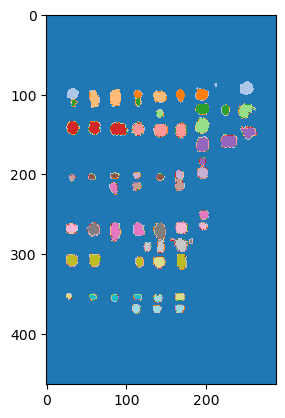

In [10]:
from matplotlib import pyplot as plt
focused_culsterd_pred = clusterd_pred_list[6]
plt.imshow(focused_culsterd_pred, cmap='tab20')